# Applied Machine Learning for Industrial Data Analysis

---
## Section 1 - Import Libraries

In [60]:
#bringing in all the libraries we need for this project

import warnings
warnings.filterwarnings('ignore')  # hiding unnecessary warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.tree import plot_tree
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    recall_score,
    precision_score,
    roc_curve,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE  #for handling class imbalance

sns.set_theme(style='whitegrid')  #setting a clean background for all plots

---
## Section 2 - Data Understanding & Preprocessing 

In [61]:
sensor_data = pd.read_csv(r"C:\Users\ishiv\Downloads\secom\secom.data", sep=' ', header=None)
original_data = sensor_data.copy()

label_info = pd.read_csv(r"C:\Users\ishiv\Downloads\secom\secom_labels.data", sep=' ', header=None, names=['result', 'time'])
labels = label_info['result']

print('Dataset Samples:', sensor_data.shape[0])
print('Sensor features:', sensor_data.shape[1])
print('Unique label values:', labels.unique())
print('-1 = pass,  1 = failed')

Dataset Samples: 1567
Sensor features: 590
Unique label values: [-1  1]
-1 = pass,  1 = failed


In [62]:
total_cells = sensor_data.shape[0] * sensor_data.shape[1]
missing_count = sensor_data.isna().sum().sum()

print('Total values:', total_cells)
print('Missing values:', missing_count)
print('That is', round(100 * missing_count / total_cells, 1), '% of the data')

fraction_missing = sensor_data.isna().mean()
print('Columns with more than 50% missing:', (fraction_missing > 0.5).sum())

Total values: 924530
Missing values: 41951
That is 4.5 % of the data
Columns with more than 50% missing: 28


In [63]:
#drop columns where more than half the values are missing
keep = fraction_missing[fraction_missing <= 0.5].index
sensor_data = sensor_data[keep]

print('Columns before dropping:', original_data.shape[1])
print('Columns kept:', sensor_data.shape[1])

Columns before dropping: 590
Columns kept: 562


In [64]:
#use median because sensor data has spikes that would skew the mean
filler = SimpleImputer(strategy='median')
sensor_data = pd.DataFrame(filler.fit_transform(sensor_data), columns=keep)

print('Missing values remaining:', sensor_data.isna().sum().sum())

Missing values remaining: 0


In [65]:
variance = sensor_data.var()
sensor_data = sensor_data[variance[variance > 0].index]

print('Features remaining after removing flat columns:', sensor_data.shape[1])

Features remaining after removing flat columns: 446


In [66]:
#scale everything to mean=0, std=1
sc = StandardScaler()
scaled = pd.DataFrame(sc.fit_transform(sensor_data), columns=sensor_data.columns)

print('Final dataset shape after all preprocessing:', scaled.shape)

Final dataset shape after all preprocessing: (1567, 446)


In [67]:
#sklearn expects 0/1 not -1/1
y = labels.map({-1: 0, 1: 1})
y = y.reset_index(drop=True)

print('Label counts after converting:')
print(y.value_counts())

Label counts after converting:
result
0    1463
1     104
Name: count, dtype: int64


In [68]:
#counting how many products passed and how many failed
passes = (labels == -1).sum()
fails = (labels ==  1).sum()

print('Products - passed:', passes)
print('Products - failed:', fails)
print('Fail rate:', round(100 * fails / len(labels), 1), '%')
print()
print('Only about 7% of products fail - the dataset is heavily imbalanced')


Products - passed: 1463
Products - failed: 104
Fail rate: 6.6 %

Only about 7% of products fail - the dataset is heavily imbalanced


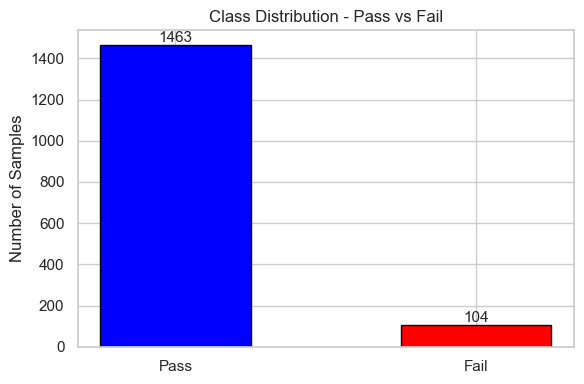

In [69]:
#plotting a bar chart to show how imbalanced the two classes are
plt.figure(figsize=(6, 4))
plt.bar(['Pass', 'Fail'], [passes, fails], color=['blue', 'red'], edgecolor='black', width=0.5)
plt.text(0, passes + 15, str(passes), ha='center', fontsize=11)  # adding count on top of Pass bar
plt.text(1, fails  + 15, str(fails),  ha='center', fontsize=11)  # adding count on top of Fail bar
plt.title('Class Distribution - Pass vs Fail')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

---
## Section 3 - Exploratory Data Analysis 

In [70]:
print('Statistical Summary of first 10 features after Scaling:')
scaled.iloc[:, :10].describe().round(3)

Statistical Summary of first 10 features after Scaling:


,0,1,2,3,4,6,7,8,9,10
count,1567.000,1567.000,1567.000,1567.000,1567.000,1567.000,1567.000,1567.000,1567.000,1567.000
mean,0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.692,-4.203,-4.763,-3.174,-0.062,-3.059,-13.638,-3.682,-3.480,-3.771
25%,-0.650,-0.536,-0.662,-0.708,-0.056,-0.512,-0.081,-0.699,-0.659,-0.618
50%,-0.040,0.044,0.018,-0.251,-0.051,0.064,0.064,-0.017,-0.030,0.027
75%,0.573,0.535,0.596,0.443,-0.047,0.550,0.221,0.731,0.612,0.619
max,4.655,4.371,3.906,5.276,19.798,4.533,0.758,2.622,5.015,5.687


In [71]:
feature_skew = scaled.skew()
skewed_count = (feature_skew.abs() > 1).sum()

print('Features with skewness over 1 or under -1:', skewed_count)

Features with skewness over 1 or under -1: 303


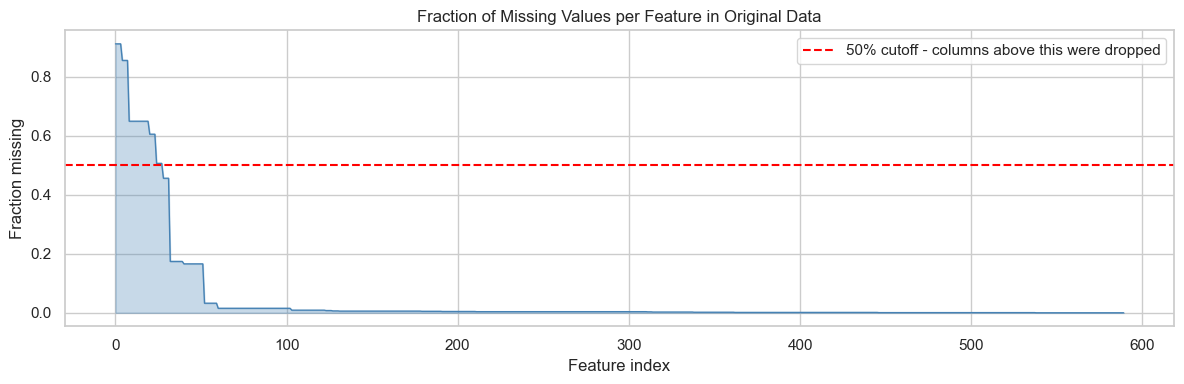

In [72]:
#plotting how much data was missing in the original raw file
#using original_data here so we show what it looked like before cleaning
#features above the red line had more than 50% missing and were dropped
missing_per_col = original_data.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
plt.plot(missing_per_col.values, color='steelblue', linewidth=1)
plt.axhline(0.5, color='red', linestyle='--', label='50% cutoff - columns above this were dropped')
plt.fill_between(range(len(missing_per_col)), missing_per_col.values, alpha=0.3, color='steelblue')
plt.title('Fraction of Missing Values per Feature in Original Data')
plt.xlabel('Feature index')
plt.ylabel('Fraction missing')
plt.legend()
plt.tight_layout()
plt.show()

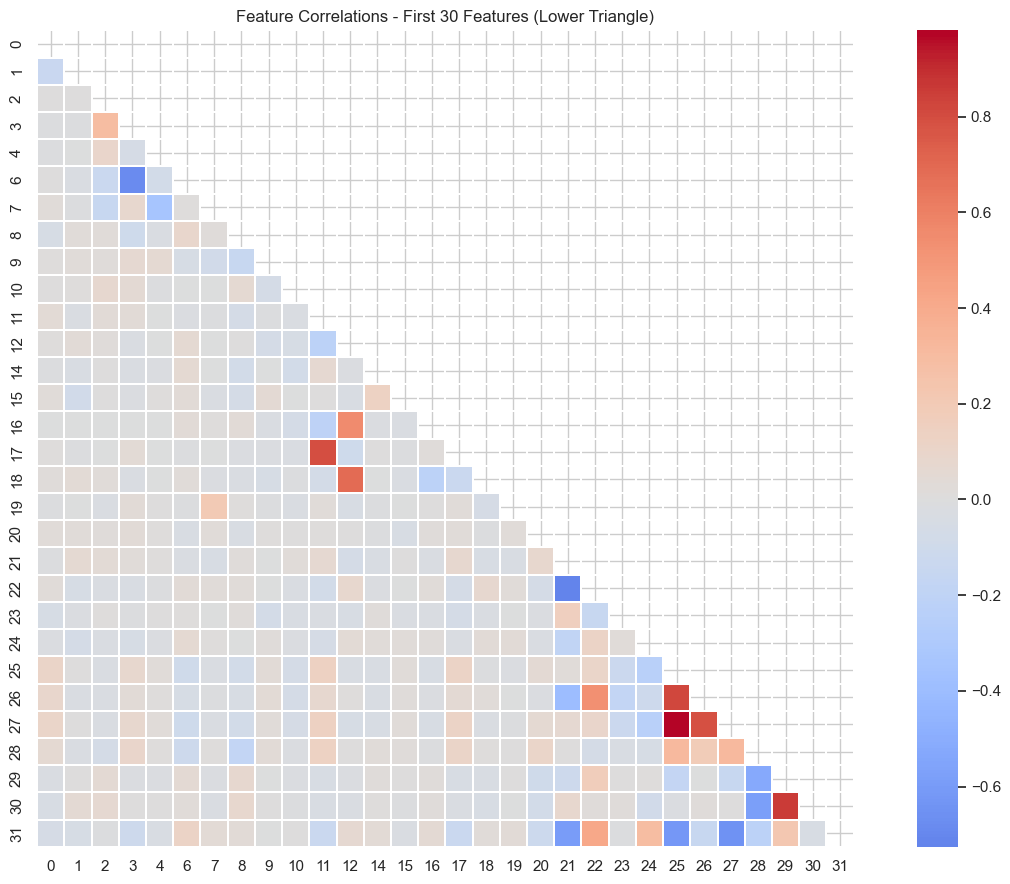

In [74]:
#plotting a correlation heatmap for the first 30 features
first30 = scaled.iloc[:, :30].corr()  # calculating correlations between first 30 features

mask = np.triu(np.ones_like(first30, dtype=bool))  # creating a mask to hide the upper triangle

plt.figure(figsize=(13, 9))
sns.heatmap(first30, mask=mask, cmap='coolwarm', center=0, linewidths=0.3, square=True, annot=False)
plt.title('Feature Correlations - First 30 Features (Lower Triangle)')
plt.tight_layout()
plt.show()

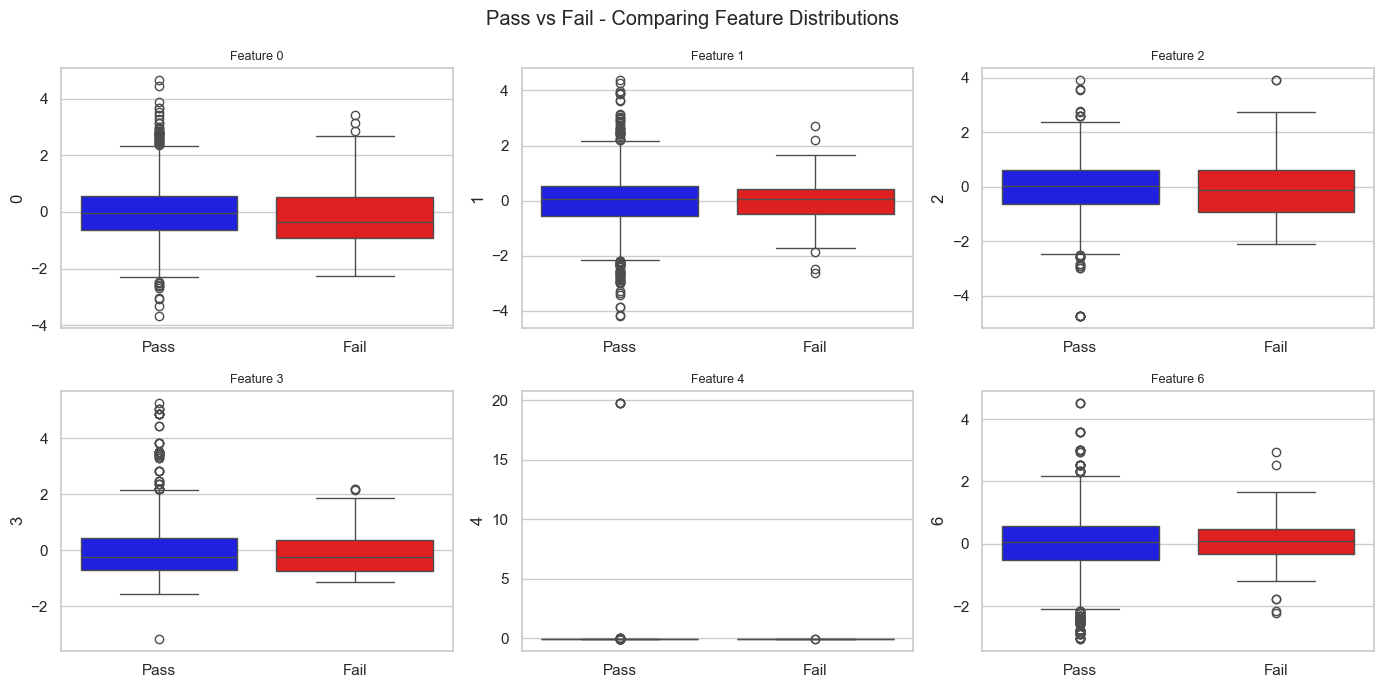

In [75]:
#plotting boxplots to compare how Pass and Fail samples look for the first 6 features
#if the boxes are in different positions it means the feature helps separate the classes
plot_df = scaled.iloc[:, :6].copy()
plot_df['outcome'] = y.map({0: 'Pass', 1: 'Fail'}).values  # adding outcome labels for the plot

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i in range(2):
    for j in range(3):
        feature = scaled.columns[i * 3 + j]  # picking each feature one by one
        sns.boxplot(data=plot_df, x='outcome', y=feature,
                    palette={'Pass': 'blue', 'Fail': 'red'},
                    ax=axes[i][j])
        axes[i][j].set_title('Feature ' + str(feature), fontsize=9)
        axes[i][j].set_xlabel('')

plt.suptitle('Pass vs Fail - Comparing Feature Distributions')
plt.tight_layout()
plt.show()

---
## Section 4 - Outlier Analysis

In [76]:
#contamination=0.05 means we expect about 5% of samples to be outliers
iso = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso.fit_predict(scaled)

found = (outlier_labels == -1).sum()
print('Outliers found:', found)
print('That is', round(100 * found / len(outlier_labels), 1), '% of all samples')

Outliers found: 79
That is 5.0 % of all samples


In [77]:
is_outlier = outlier_labels == -1

fail_rate_in_outliers = round(y[is_outlier].mean(), 3)
overall_fail_rate = round(y.mean(), 3)

print('Fail rate among the found outliers:', fail_rate_in_outliers)
print('Fail rate in the full dataset:', overall_fail_rate)

Fail rate among the found outliers: 0.139
Fail rate in the full dataset: 0.066


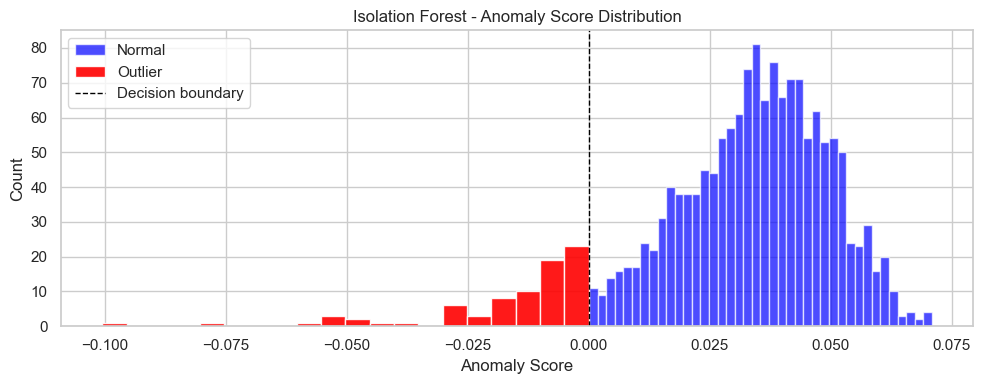

In [78]:
#isolation forest gives each sample a score — lower = more anomalous
scores = iso.decision_function(scaled)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores[outlier_labels == 1],  bins=40, color='blue', alpha=0.7, label='Normal')
ax.hist(scores[outlier_labels == -1], bins=20, color='red',    alpha=0.9, label='Outlier')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Decision boundary')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Count')
ax.set_title('Isolation Forest - Anomaly Score Distribution')
ax.legend()
plt.tight_layout()
plt.show()

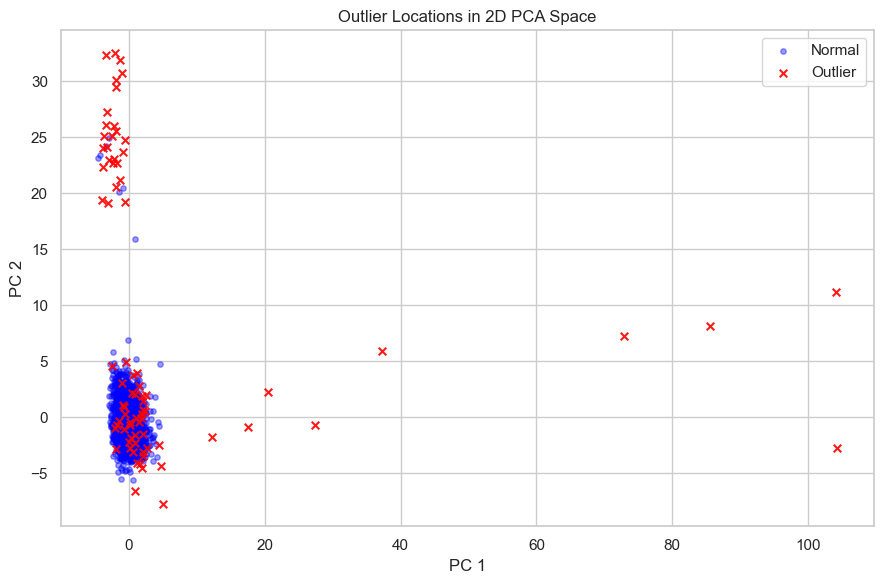

In [80]:
#reducing the data to 2D using PCA so we can plot where the outliers sit
quick_pca = PCA(n_components=2, random_state=42)
two_d = quick_pca.fit_transform(scaled)  # compressing everything into 2 dimensions

normal_pts = two_d[outlier_labels ==  1]  # grabbing the normal samples
unusual_pts = two_d[outlier_labels == -1]  # grabbing the outlier samples

#plotting normal and outlier points in different colours
plt.figure(figsize=(9, 6))
plt.scatter(normal_pts[:, 0],  normal_pts[:, 1],  c='blue', alpha=0.4, s=15, label='Normal')
plt.scatter(unusual_pts[:, 0], unusual_pts[:, 1], c='red', alpha=0.9, s=30, marker='x', label='Outlier')
plt.title('Outlier Locations in 2D PCA Space')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 5 - Dimensionality Reduction (PCA) 

In [81]:
full_pca = PCA(random_state=42)
full_pca.fit(scaled)

running_total = np.cumsum(full_pca.explained_variance_ratio_)

#findig how many components get us to 95% variance
num_comp = 0
for i in range(len(running_total)):
    if running_total[i] >= 0.95:
        num_comp = i + 1
        break

print('Original number of features:', scaled.shape[1])
print('Components needed to keep 95% of the variance:', num_comp)

Original number of features: 446
Components needed to keep 95% of the variance: 162


In [82]:
table = pd.DataFrame({
    'Component': range(1, 11),
    'Variance %': (full_pca.explained_variance_ratio_[:10] * 100).round(2),
    'Cumulative %': (running_total[:10] * 100).round(2)
})
print(table.to_string(index=False))

top_var = round(full_pca.explained_variance_ratio_[0] * 100, 2)
print('\nPC1 explains', top_var,'%')

 Component  Variance %  Cumulative %
         1        5.73          5.73
         2        3.86          9.58
         3        2.99         12.57
         4        2.68         15.25
         5        2.19         17.44
         6        2.08         19.52
         7        1.93         21.45
         8        1.90         23.35
         9        1.71         25.06
        10        1.54         26.60

PC1 explains 5.73 %


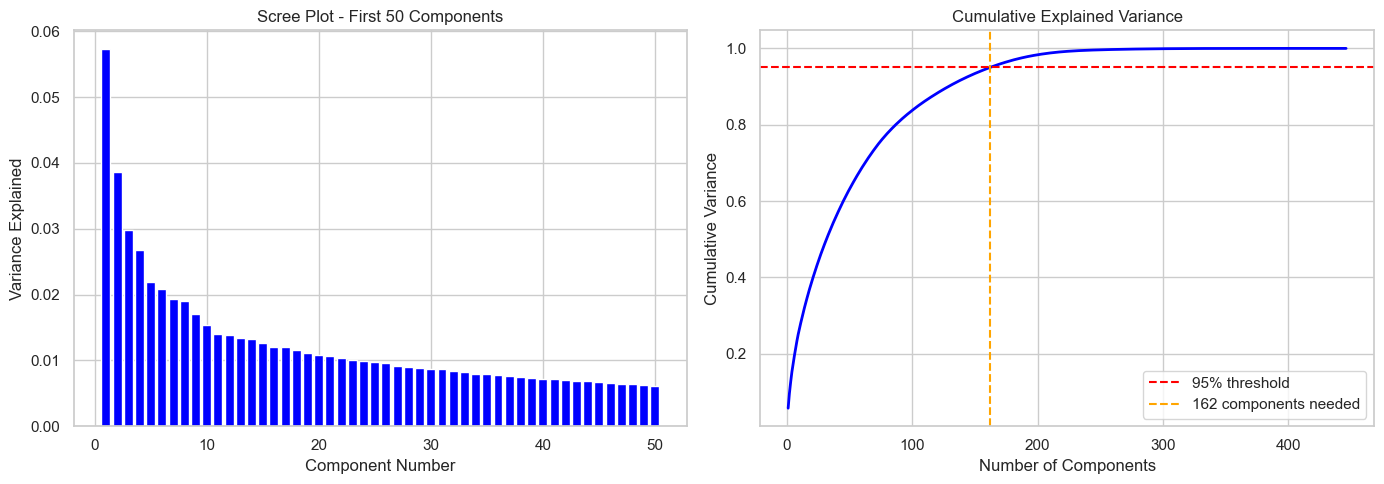

In [83]:
#plotting the scree plot and cumulative variance curve side by side
#scree plot shows how much each component contributes
#cumulative plot shows when we hit the 95% threshold
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5))

#plotting variance per component for the first 50
left.bar(range(1, 51), full_pca.explained_variance_ratio_[:50], color='blue')
left.set_title('Scree Plot - First 50 Components')
left.set_xlabel('Component Number')
left.set_ylabel('Variance Explained')

#plotting how variance adds up as we include more components
right.plot(range(1, len(running_total) + 1), running_total, color='blue', linewidth=2)
right.axhline(0.95, color='red', linestyle='--', label='95% threshold')
right.axvline(num_comp, color='orange', linestyle='--', label=str(num_comp) + ' components needed')
right.set_title('Cumulative Explained Variance')
right.set_xlabel('Number of Components')
right.set_ylabel('Cumulative Variance')
right.legend()

plt.tight_layout()
plt.show()

In [84]:
pca = PCA(n_components=num_comp, random_state=42)
reduced = pca.fit_transform(scaled)

kept = round(pca.explained_variance_ratio_.sum() * 100, 2)
print('Shape before PCA:', scaled.shape)
print('Shape after PCA: ', reduced.shape)
print('Variance retained:', kept, '%')

Shape before PCA: (1567, 446)
Shape after PCA:  (1567, 162)
Variance retained: 94.94 %


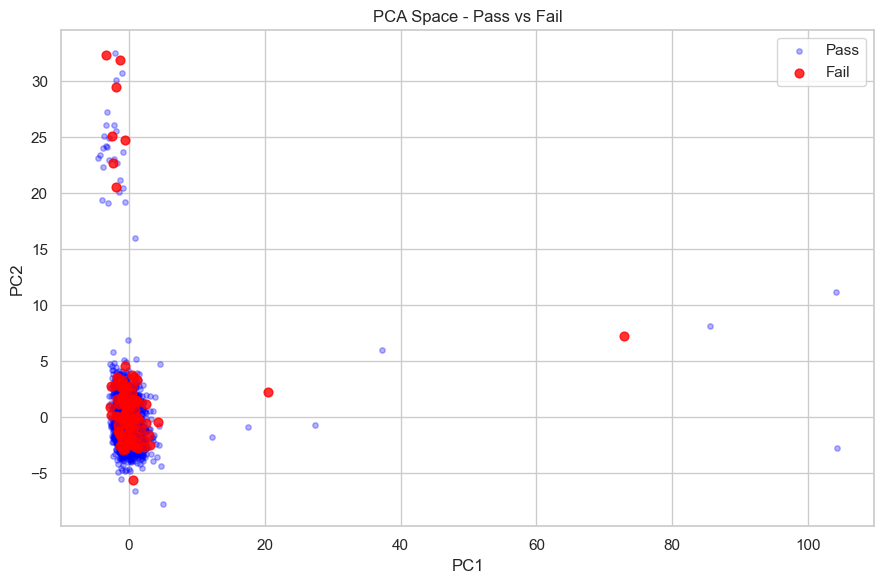

In [85]:
#plot the first two PCA components coloured by the actual label
#gives a visual feel for how separable the classes are in reduced space
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(reduced[y==0, 0], reduced[y==0, 1],
           c='blue', alpha=0.3, s=15, label='Pass')
ax.scatter(reduced[y==1, 0], reduced[y==1, 1],
           c='red', alpha=0.8, s=40, label='Fail', zorder=3)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA Space - Pass vs Fail')
ax.legend()
plt.tight_layout()
plt.show()

### Comparing KNN Before vs After PCA (using F1 Score)


In [86]:
X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
    scaled, y, test_size=0.2, random_state=42, stratify=y
)
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    reduced, y, test_size=0.2, random_state=42, stratify=y
)

knn_orig = KNeighborsClassifier(n_neighbors=7)
knn_orig.fit(X_orig_train, y_orig_train)
f1_before = f1_score(y_orig_test, knn_orig.predict(X_orig_test), pos_label=1, zero_division=0)

knn_pca = KNeighborsClassifier(n_neighbors=7)
knn_pca.fit(X_pca_train, y_pca_train)
f1_after = f1_score(y_pca_test, knn_pca.predict(X_pca_test), pos_label=1, zero_division=0)

print('KNN Fail-class F1 before PCA:', round(f1_before, 4))
print('KNN Fail-class F1 after PCA: ', round(f1_after, 4))
print()
print('We went from', scaled.shape[1], 'features down to', reduced.shape[1], 'components')

KNN Fail-class F1 before PCA: 0.0
KNN Fail-class F1 after PCA:  0.0

We went from 446 features down to 162 components


---
## Section 6 - K-Means Clustering

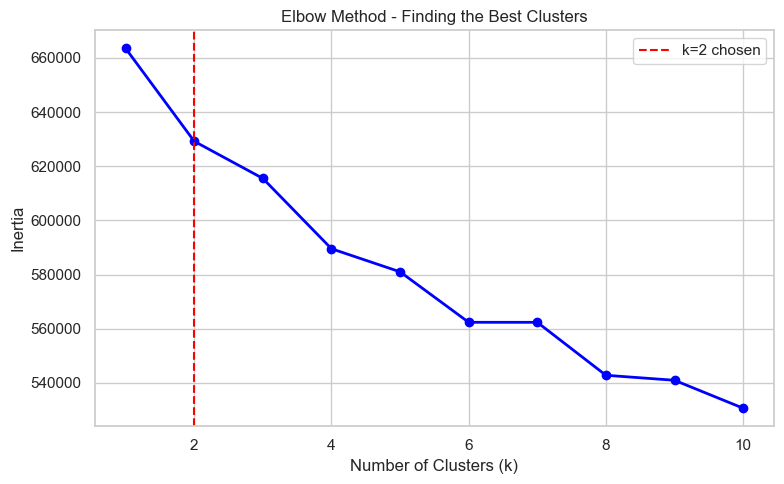

In [87]:
inertia_scores = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(reduced)
    inertia_scores.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_scores, marker='o', color='blue', linewidth=2)
plt.axvline(x=2, color='red', linestyle='--', label='k=2 chosen')
plt.title('Elbow Method - Finding the Best Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
#fitting K-Means with k=2 and getting a cluster label for each sample
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
groups = kmeans.fit_predict(reduced)  # assigning each sample to a cluster

print('Group 0 has', (groups == 0).sum(), 'samples')
print('Group 1 has', (groups == 1).sum(), 'samples')


Group 0 has 1563 samples
Group 1 has 4 samples


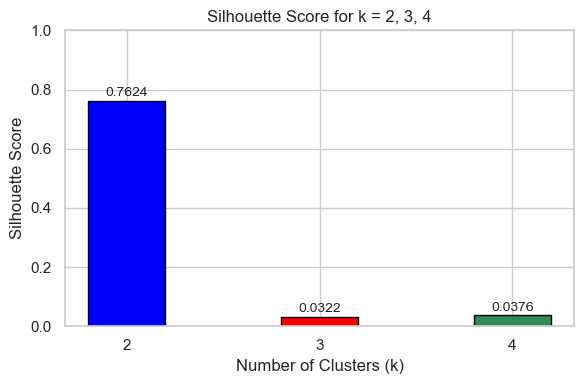

In [31]:
sil = silhouette_score(reduced, groups)
#compare silhouette across k=2,3,4 to confirm k=2 is the best choice
k_vals   = [2, 3, 4]
sil_vals = []
for k in k_vals:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(reduced)
    sil_vals.append(round(silhouette_score(reduced, lbl), 4))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(k_vals, sil_vals, color=['blue', 'red', 'seagreen'],
              edgecolor='black', width=0.4)
ax.set_xticks(k_vals)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score for k = 2, 3, 4')
ax.set_ylim(0, 1)

for bar, val in zip(bars, sil_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

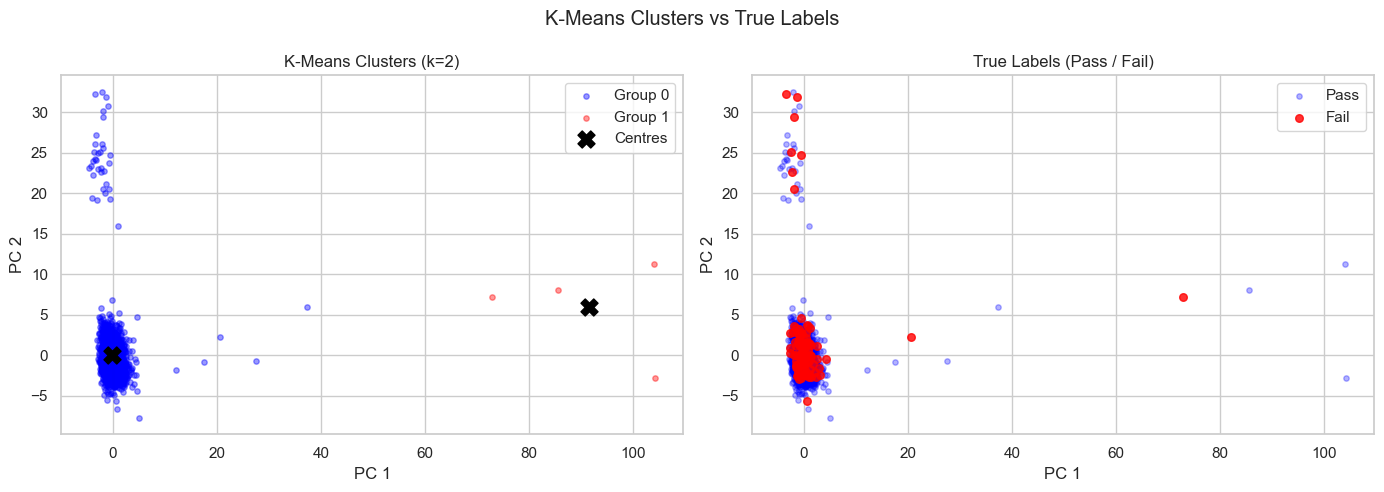

In [89]:
#plotting K-Means clusters alongside the true Pass/Fail labels side by side
#this lets us see if the clusters line up with the real outcomes
passed = (y == 0).values  # boolean mask for Pass samples
failed = (y == 1).values  # boolean mask for Fail samples

group0_pts = reduced[groups == 0]  # grabbing points in cluster 0
group1_pts = reduced[groups == 1]  # grabbing points in cluster 1

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5))

# left plot shows what K-Means found
left.scatter(group0_pts[:, 0], group0_pts[:, 1], c='blue', alpha=0.4, s=15, label='Group 0')
left.scatter(group1_pts[:, 0], group1_pts[:, 1], c='red',    alpha=0.4, s=15, label='Group 1')
left.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X', s=150, label='Centres')
left.set_title('K-Means Clusters (k=2)')
left.set_xlabel('PC 1')
left.set_ylabel('PC 2')
left.legend()

# right plot shows the actual Pass/Fail labels
right.scatter(reduced[passed, 0], reduced[passed, 1], c='blue', alpha=0.3, s=15, label='Pass')
right.scatter(reduced[failed, 0], reduced[failed, 1], c='red',    alpha=0.8, s=30, label='Fail')
right.set_title('True Labels (Pass / Fail)')
right.set_xlabel('PC 1')
right.set_ylabel('PC 2')
right.legend()

plt.suptitle('K-Means Clusters vs True Labels')
plt.tight_layout()
plt.show()

In [90]:
group0_fail_rate = round(y[groups == 0].mean(), 3)
group1_fail_rate = round(y[groups == 1].mean(), 3)

print('Fail rate in Group 0:', group0_fail_rate)
print('Fail rate in Group 1:', group1_fail_rate)
print()
if group0_fail_rate > group1_fail_rate:
    print('Group 0 captured more failures - mostly abnormal runs')
    print('Group 1 is mainly normal passing products')
else:
    print('Group 1 captured more failures - mostly abnormal runs')
    print('Group 0 is mainly normal passing products')

Fail rate in Group 0: 0.066
Fail rate in Group 1: 0.25

Group 1 captured more failures - mostly abnormal runs
Group 0 is mainly normal passing products


---
## Section 7 - Classification 

In [91]:
#stratify keeps the same fail rate in both splits
X_train, X_test, y_train, y_test = train_test_split(
    reduced, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples: ', X_test.shape[0])
print('Fail rate in training set:', round(y_train.mean(), 3))
print('Fail rate in testing set: ', round(y_test.mean(), 3))

Training samples: 1253
Testing samples:  314
Fail rate in training set: 0.066
Fail rate in testing set:  0.067


In [92]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# SMOTE only touches the training set - test set stays as real data
print('Training set BEFORE SMOTE:', pd.Series(y_train).value_counts().to_dict())
print('Training set AFTER  SMOTE:', pd.Series(y_train_sm).value_counts().to_dict())
print()
print('Test set stays untouched:', pd.Series(y_test).value_counts().to_dict())

Training set BEFORE SMOTE: {0: 1170, 1: 83}
Training set AFTER  SMOTE: {0: 1170, 1: 1170}

Test set stays untouched: {0: 293, 1: 21}


In [93]:
#KNN doesn't have class_weight, so SMOTE is how we fix the imbalance here
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sm, y_train_sm)

knn_train_pred = knn.predict(X_train_sm)
knn_test_pred  = knn.predict(X_test)

print('--- KNN Results("trained on SMOTE data") ---')
print(classification_report(y_test, knn_test_pred, target_names=['Pass', 'Fail']))

# drop the threshold from 0.5 to 0.35 to catch more failures
knn_probs      = knn.predict_proba(X_test)[:, 1]
knn_tuned_pred = (knn_probs >= 0.35).astype(int)

print('--- KNN Results("threshold = 0.35") ---')
print(classification_report(y_test, knn_tuned_pred, target_names=['Pass', 'Fail']))
print('lower threshold catches more failures but also gives more false alarms')

--- KNN Results("trained on SMOTE data") ---
              precision    recall  f1-score   support

        Pass       0.94      0.30      0.46       293
        Fail       0.07      0.71      0.12        21

    accuracy                           0.33       314
   macro avg       0.50      0.51      0.29       314
weighted avg       0.88      0.33      0.44       314

--- KNN Results("threshold = 0.35") ---
              precision    recall  f1-score   support

        Pass       0.93      0.24      0.38       293
        Fail       0.07      0.76      0.12        21

    accuracy                           0.27       314
   macro avg       0.50      0.50      0.25       314
weighted avg       0.88      0.27      0.36       314

lower threshold catches more failures but also gives more false alarms


In [100]:
#depth = 7 works better now that SMOTE balanced the classes
dt = DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42)
dt.fit(X_train_sm, y_train_sm)

dt_train_pred = dt.predict(X_train_sm)
dt_test_pred  = dt.predict(X_test)

print('--- Decision Tree Results ---')
print(classification_report(y_test, dt_test_pred, target_names=['Pass', 'Fail']))

--- Decision Tree Results ---
              precision    recall  f1-score   support

        Pass       0.95      0.77      0.85       293
        Fail       0.11      0.38      0.16        21

    accuracy                           0.74       314
   macro avg       0.53      0.57      0.51       314
weighted avg       0.89      0.74      0.80       314



In [98]:
#tryg a few values of C to pick the best one using 5-fold CV scored on F1
print('Running GridSearch for best C... (takes ~30 sec)')

param_grid = {'C': [0.1, 0.5, 1.0, 5.0, 10.0]}
gs = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)
gs.fit(X_train_sm, y_train_sm)

best_C = gs.best_params_['C']
print('Best C:', best_C)

svm = gs.best_estimator_
svm_train_pred = svm.predict(X_train_sm)
svm_test_pred  = svm.predict(X_test)

print()
print('--- SVM Results (best C =', best_C, ') ---')
print(classification_report(y_test, svm_test_pred, target_names=['Pass', 'Fail']))

Running GridSearch for best C... (takes ~30 sec)
Best C: 5.0

--- SVM Results (best C = 5.0 ) ---
              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97       293
        Fail       1.00      0.05      0.09        21

    accuracy                           0.94       314
   macro avg       0.97      0.52      0.53       314
weighted avg       0.94      0.94      0.91       314



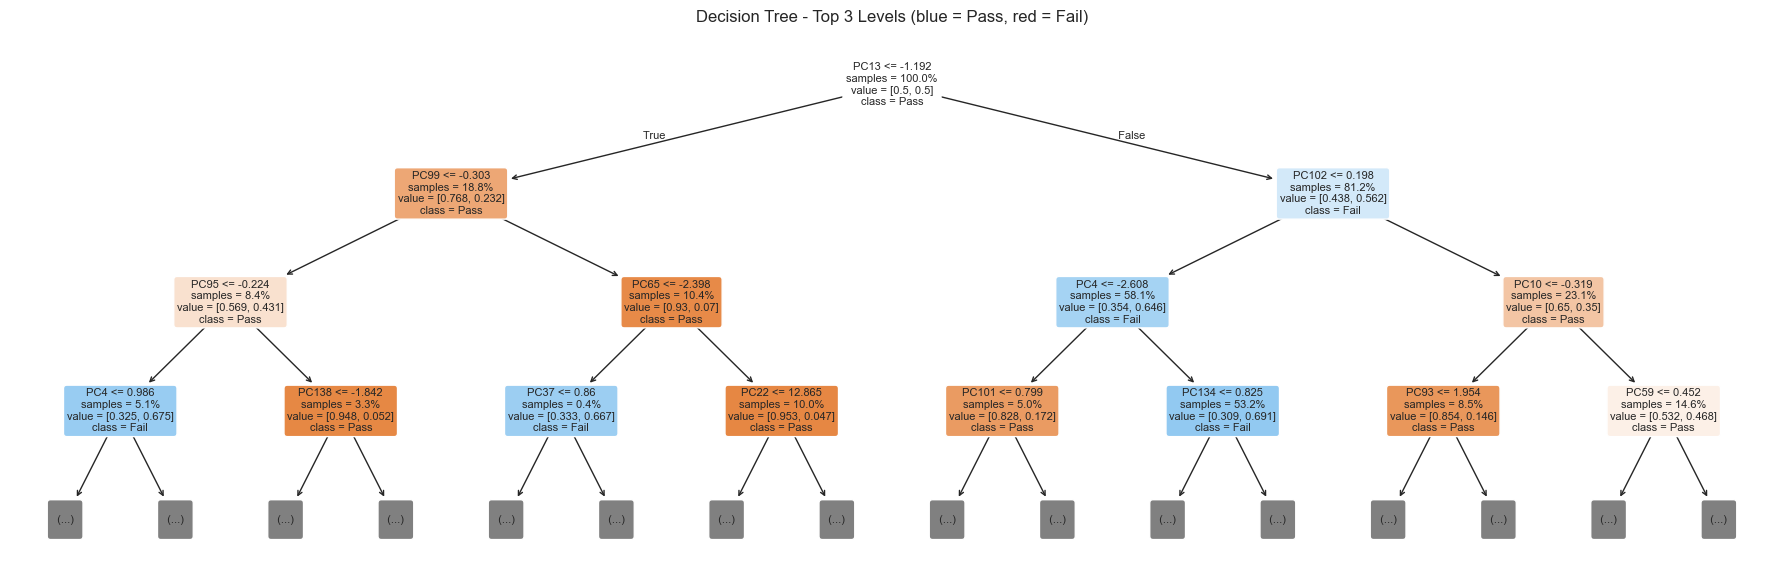

In [96]:
#plot the top 3 levels of the tree so we can see what splits it learned
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(dt, max_depth=3, feature_names=[f'PC{i+1}' for i in range(reduced.shape[1])],
          class_names=['Pass', 'Fail'], filled=True, rounded=True,
          impurity=False, proportion=True, ax=ax, fontsize=8)
ax.set_title('Decision Tree - Top 3 Levels (blue = Pass, red = Fail)')
plt.tight_layout()
plt.show()

In [101]:
models_preds = {
    'KNN (default)':     knn_test_pred,
    'KNN (thresh=0.35)': knn_tuned_pred,
    'Decision Tree':     dt_test_pred,
    'SVM (tuned C)':     svm_test_pred,
}

rows = []
for name, preds in models_preds.items():
    rows.append({
        'Model':          name,
        'Fail Recall':    round(recall_score(y_test, preds, pos_label=1), 4),
        'Fail Precision': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'F1 (Fail)':      round(f1_score(y_test, preds, pos_label=1, zero_division=0), 4),
    })

comp_summary = pd.DataFrame(rows)
print(comp_summary.to_string(index=False))
print()
print('Best F1 model:', comp_summary.loc[comp_summary['F1 (Fail)'].idxmax(), 'Model'])

            Model  Fail Recall  Fail Precision  F1 (Fail)
    KNN (default)       0.7143          0.0685     0.1250
KNN (thresh=0.35)       0.7619          0.0669     0.1231
    Decision Tree       0.3810          0.1053     0.1649
    SVM (tuned C)       0.0476          1.0000     0.0909

Best F1 model: Decision Tree


In [102]:
#single 80/20 split is vague with only 104 fail samples, CV gives a more stable picture
#using best_C from GridSearch for SVM so results are comparable to the main model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Cross-Validation F1 (Fail class):')
print()

cv_results = {}
for name, clf in [
    ('KNN',           KNeighborsClassifier(n_neighbors=7)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42)),
    ('SVM',           SVC(kernel='rbf', C=best_C, class_weight='balanced', random_state=42))
]:
    scores = cross_val_score(clf, reduced, y, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f'  {name:<18} mean F1 = {scores.mean():.4f}  ±  {scores.std():.4f}')

5-Fold Cross-Validation F1 (Fail class):

  KNN                mean F1 = 0.0000  ±  0.0000
  Decision Tree      mean F1 = 0.1010  ±  0.0316
  SVM                mean F1 = 0.0348  ±  0.0426


---
## Section 8 - Model Evaluation

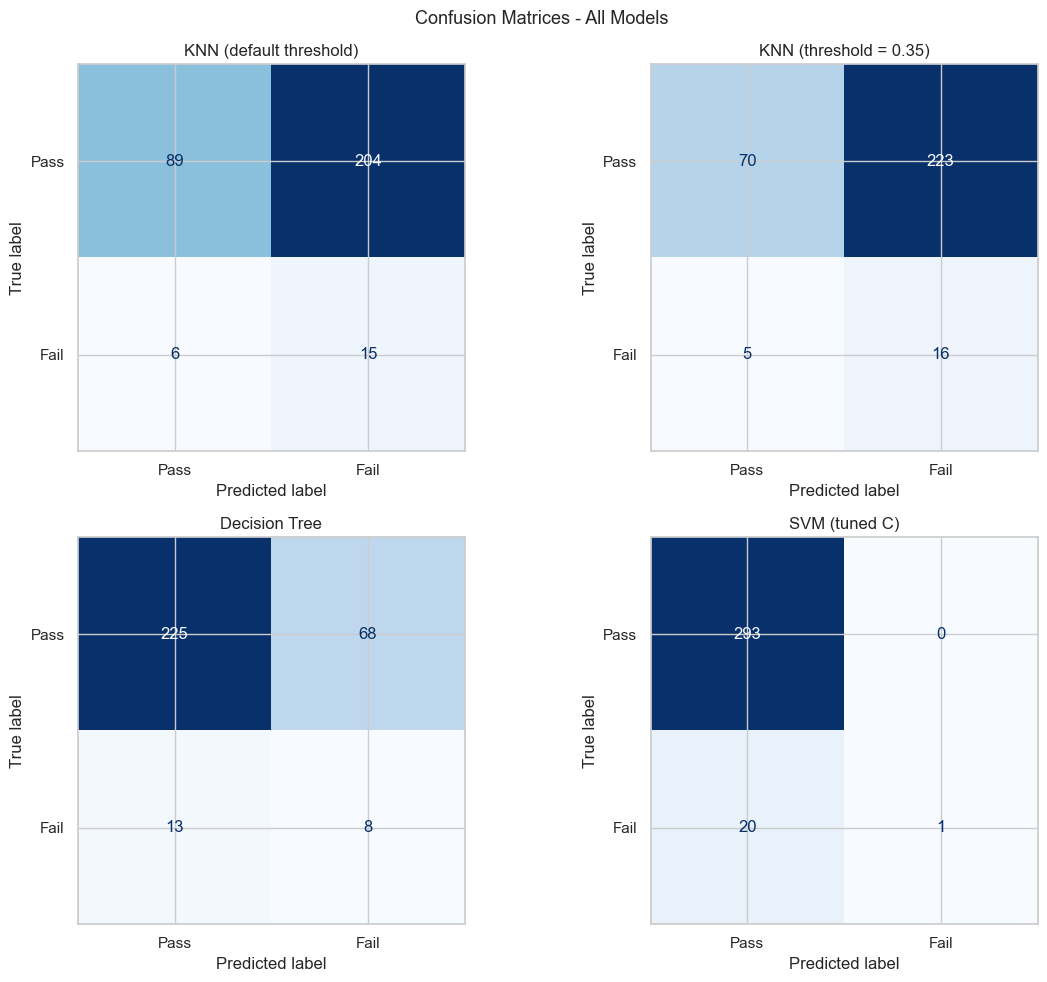

In [103]:
#top-right cell in each matrix is the failures the model missed (false negatives)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay(confusion_matrix(y_test, knn_test_pred),
    display_labels=['Pass', 'Fail']).plot(ax=axes[0][0], colorbar=False, cmap='Blues')
axes[0][0].set_title('KNN (default threshold)')

ConfusionMatrixDisplay(confusion_matrix(y_test, knn_tuned_pred),
    display_labels=['Pass', 'Fail']).plot(ax=axes[0][1], colorbar=False, cmap='Blues')
axes[0][1].set_title('KNN (threshold = 0.35)')

ConfusionMatrixDisplay(confusion_matrix(y_test, dt_test_pred),
    display_labels=['Pass', 'Fail']).plot(ax=axes[1][0], colorbar=False, cmap='Blues')
axes[1][0].set_title('Decision Tree')

ConfusionMatrixDisplay(confusion_matrix(y_test, svm_test_pred),
    display_labels=['Pass', 'Fail']).plot(ax=axes[1][1], colorbar=False, cmap='Blues')
axes[1][1].set_title('SVM (tuned C)')

plt.suptitle('Confusion Matrices - All Models', fontsize=13)
plt.tight_layout()
plt.show()

In [104]:
eval_summary = pd.DataFrame({
    'Model': ['KNN (default)', 'KNN (thresh=0.35)', 'Decision Tree', 'SVM (tuned C)'],
    'Fail Recall': [round(recall_score(y_test, p, pos_label=1), 4)
                       for p in [knn_test_pred, knn_tuned_pred, dt_test_pred, svm_test_pred]],
    'Fail Precision': [round(precision_score(y_test, p, pos_label=1, zero_division=0), 4)
                       for p in [knn_test_pred, knn_tuned_pred, dt_test_pred, svm_test_pred]],
    'F1 (Fail)': [round(f1_score(y_test, p, pos_label=1, zero_division=0), 4)
                       for p in [knn_test_pred, knn_tuned_pred, dt_test_pred, svm_test_pred]],
})

print(eval_summary.to_string(index=False))

            Model  Fail Recall  Fail Precision  F1 (Fail)
    KNN (default)       0.7143          0.0685     0.1250
KNN (thresh=0.35)       0.7619          0.0669     0.1231
    Decision Tree       0.3810          0.1053     0.1649
    SVM (tuned C)       0.0476          1.0000     0.0909


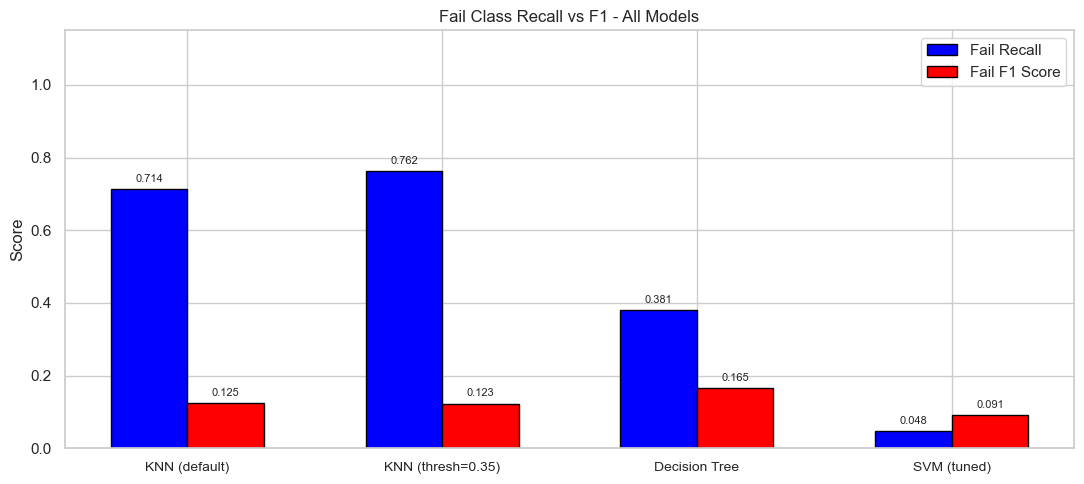

In [105]:
model_names = ['KNN (default)', 'KNN (thresh=0.35)', 'Decision Tree', 'SVM (tuned)']

recall_list = [round(recall_score(y_test, p, pos_label=1), 3)
               for p in [knn_test_pred, knn_tuned_pred, dt_test_pred, svm_test_pred]]

f1_list = [round(f1_score(y_test, p, pos_label=1, zero_division=0), 3)
           for p in [knn_test_pred, knn_tuned_pred, dt_test_pred, svm_test_pred]]

x = np.arange(len(model_names))
bar_w = 0.3

fig, ax = plt.subplots(figsize=(11, 5))
rb = ax.bar(x - bar_w/2, recall_list, bar_w, label='Fail Recall',   color='blue', edgecolor='black')
fb = ax.bar(x + bar_w/2, f1_list, bar_w, label='Fail F1 Score', color='red', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Fail Class Recall vs F1 - All Models')
ax.legend()

for bar in list(rb) + list(fb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            str(bar.get_height()), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

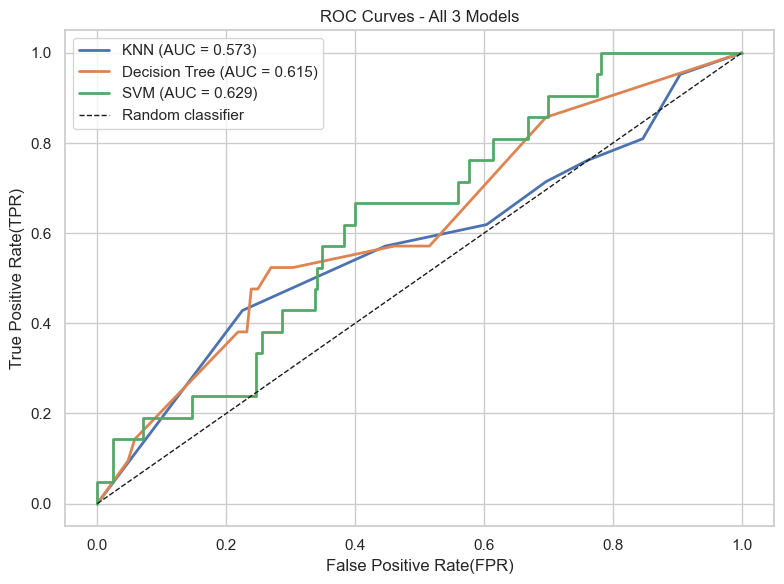

In [108]:
plt.figure(figsize=(8, 6))

for name, clf in [('KNN', knn), ('Decision Tree', dt), ('SVM', svm)]:
    probs = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {round(auc, 3)})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate(FPR)')
plt.ylabel('True Positive Rate(TPR)')
plt.title('ROC Curves - All 3 Models')
plt.legend()
plt.tight_layout()
plt.show()

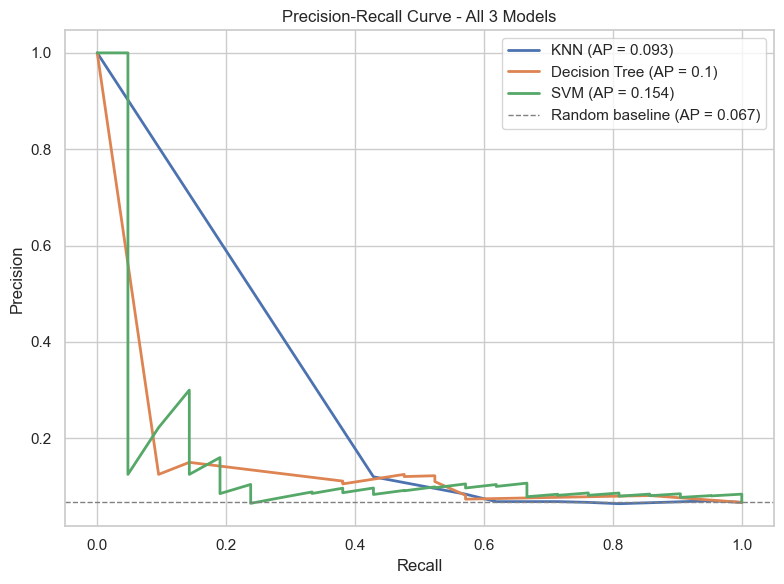

In [107]:
#PR curve is better than ROC for imbalanced data
plt.figure(figsize=(8, 6))

for name, clf in [('KNN', knn), ('Decision Tree', dt), ('SVM', svm)]:
    probs = clf.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(rec, prec, linewidth=2, label=f'{name} (AP = {round(ap, 3)})')

baseline = round(y_test.mean(), 3)
plt.axhline(baseline, color='grey', linestyle='--', linewidth=1,
            label=f'Random baseline (AP = {baseline})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - All 3 Models')
plt.legend()
plt.tight_layout()
plt.show()